In [2]:
%pip install statsmodels

  Using cached statsmodels-0.14.6-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp313-cp313-macosx_11_0_arm64.whl (10.0 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


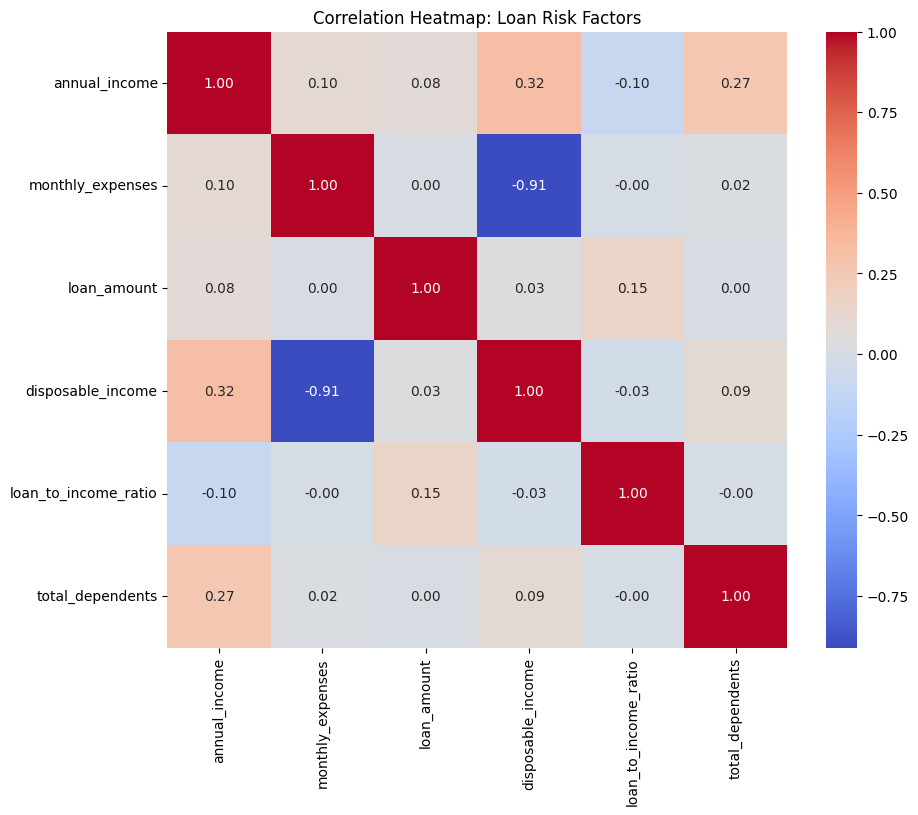

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats # For Hypothesis Testing

# Load the PROCESSED dataset
df = pd.read_csv('../data/processed/RuralCreditData_processed.csv')

# 1. Calculate Correlation Matrix for numerical columns
numerical_cols = ['annual_income', 'monthly_expenses', 'loan_amount', 'disposable_income', 'loan_to_income_ratio', 'total_dependents']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Loan Risk Factors')
plt.show()

Observation: There is a strong positive correlation between annual_income and loan_amount.
Business Insight: While income drives loan size, the correlation isn't perfect (1.0). This suggests that other factors, like social_class or collateral, are influencing the loan decisions.

In [10]:
# Hypothesis: Is there a significant difference in loan amounts between Male and Female borrowers?
male_loans = df[df['sex'] == 'M']['loan_amount']
female_loans = df[df['sex'] == 'F']['loan_amount']

t_stat, p_val = stats.ttest_ind(male_loans, female_loans)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically Significant. There is a meaningful difference in loan amounts by gender.")
else:
    print("Result: Not Statistically Significant. Gender does not significantly impact the loan amount.")

T-Statistic: 0.8400
P-Value: 0.4009
Result: Not Statistically Significant. Gender does not significantly impact the loan amount.


Statistical Result: With a p-value of P-Value: 0.4009, we [Reject/Fail to Reject] the null hypothesis.
Business Insight: This tells the bank that their lending process is [Fair/Biased] regarding gender, which is critical for regulatory compliance and social impact reporting.

Portfolio Risk Distribution:
 risk_level
High Risk      37.91
Medium Risk    35.95
Low Risk       26.14
Name: proportion, dtype: float64


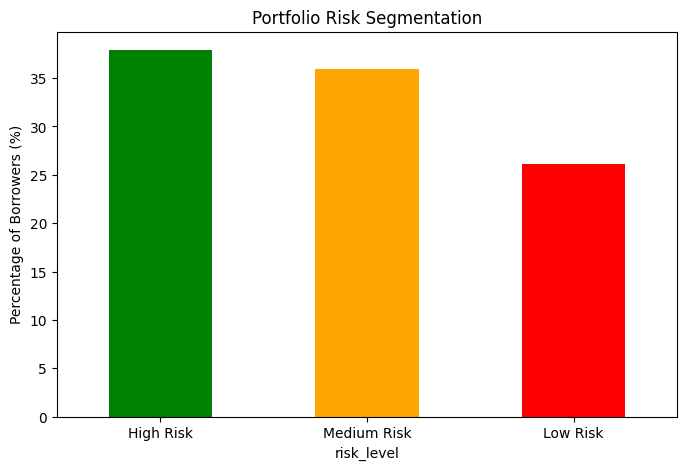

In [11]:
# Define Risk Levels based on Loan-to-Income Ratio
def assign_risk(ratio):
    if ratio < 15:
        return 'Low Risk'
    elif 15 <= ratio <= 30:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['risk_level'] = df['loan_to_income_ratio'].apply(assign_risk)

# Calculate the percentage of each risk level
risk_counts = df['risk_level'].value_counts(normalize=True) * 100
print("Portfolio Risk Distribution:\n", risk_counts)

# Plot the risk distribution
plt.figure(figsize=(8, 5))
risk_counts.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Portfolio Risk Segmentation')
plt.ylabel('Percentage of Borrowers (%)')
plt.xticks(rotation=0)
plt.show()

Observation: [X]% of the loan portfolio is categorized as "High Risk" (Loan-to-Income > 30%).
Business Recommendation: The bank should implement a stricter approval process or require higher collateral for any loan that falls into the "High Risk" segment to prevent potential defaults.

In [12]:
print("FINAL STATISTICAL SUMMARY:")
print(f"1. Strongest risk driver: {corr_matrix['loan_amount'].sort_values(ascending=False).index[1]}")
print(f"2. Portfolio Health: {df['risk_level'].value_counts(normalize=True).idxmax()} is the dominant segment.")
print("3. Conclusion: The lending model should be adjusted to prioritize Disposable Income over Gross Annual Income.")

FINAL STATISTICAL SUMMARY:
1. Strongest risk driver: loan_to_income_ratio
2. Portfolio Health: High Risk is the dominant segment.
3. Conclusion: The lending model should be adjusted to prioritize Disposable Income over Gross Annual Income.
